# ERA5

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [86]:
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

from src.datasources import era5, codab, seas5
from src.utils.raster import upsample_dataarray
from src.constants import *

In [3]:
adm1 = codab.load_codab_from_blob(admin_level=1, aoi_only=True)

In [34]:
da_era5 = era5.open_era5_rasters()

  0%|          | 0/44 [00:00<?, ?it/s]

In [35]:
da_era5

<xarray.DataArray (year: 44, valid_month: 5, y: 721, x: 1440)> Size: 914MB
dask.array<concatenate, shape=(44, 5, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * y            (y) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    spatial_ref  int64 8B 0
  * year         (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * valid_month  (valid_month) int64 40B 6 7 8 9 10
Attributes: (12/17)
    AREA_OR_POINT:     Area
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    download_date:     2024-09-26
    grid_resolution:   0.25
    ...                ...
    units:             mm/day
    version:           None
    year_issued:       None
    scale_factor:      1.0
    add_offset:        0.0
    long_name:         total precipitation

In [36]:
ORIGINAL_MO_LT_COMBOS

[{'mo': 3, 'lts': [3, 4, 5]}, {'mo': 7, 'lts': [1, 2, 3]}]

In [48]:
das = []
for mo_lt in ORIGINAL_MO_LT_COMBOS:
    da_in = da_era5.sel(valid_month=[mo_lt["mo"] + x for x in mo_lt["lts"]])
    da_in["issued_month"] = mo_lt["mo"]
    display(da_in)
    da_in_mean = da_in.mean(dim="valid_month")
    das.append(da_in_mean)

<xarray.DataArray (year: 44, valid_month: 3, y: 721, x: 1440)> Size: 548MB
dask.array<getitem, shape=(44, 3, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * y             (y) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    spatial_ref   int64 8B 0
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * valid_month   (valid_month) int64 24B 6 7 8
    issued_month  int64 8B 3
Attributes: (12/17)
    AREA_OR_POINT:     Area
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    download_date:     2024-09-26
    grid_resolution:   0.25
    ...                ...
    units:             mm/day
    version:           None
    year_issued:       None
    scale_factor:      1.0
    add_offset:        0.0
    long_name:         total precipitation

<xarray.DataArray (year: 44, valid_month: 3, y: 721, x: 1440)> Size: 548MB
dask.array<getitem, shape=(44, 3, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * y             (y) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    spatial_ref   int64 8B 0
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * valid_month   (valid_month) int64 24B 8 9 10
    issued_month  int64 8B 7
Attributes: (12/17)
    AREA_OR_POINT:     Area
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    download_date:     2024-09-26
    grid_resolution:   0.25
    ...                ...
    units:             mm/day
    version:           None
    year_issued:       None
    scale_factor:      1.0
    add_offset:        0.0
    long_name:         total precipitation

In [49]:
da_era5_season = xr.concat(das, dim="issued_month")

In [50]:
da_era5_season

<xarray.DataArray (issued_month: 2, year: 44, y: 721, x: 1440)> Size: 365MB
dask.array<concatenate, shape=(2, 44, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * y             (y) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    spatial_ref   int64 8B 0
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 16B 3 7

In [51]:
da_era5_up = upsample_dataarray(da_era5_season)

In [52]:
da_era5_clip = da_era5_up.rio.clip(adm1.geometry)

In [53]:
da_era5_clip

<xarray.DataArray (issued_month: 2, year: 44, y: 38, x: 58)> Size: 776kB
dask.array<getitem, shape=(2, 44, 38, 58), dtype=float32, chunksize=(1, 1, 38, 58), chunktype=numpy.ndarray>
Coordinates:
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 16B 3 7
  * x             (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

In [54]:
da_era5_clip_yearchunk = da_era5_clip.chunk({"year": -1})

In [55]:
da_era5_rank = da_era5_clip_yearchunk.rank(dim="year", pct=True)

In [56]:
da_era5_rank

<xarray.DataArray (issued_month: 2, year: 44, y: 38, x: 58)> Size: 2MB
dask.array<truediv, shape=(2, 44, 38, 58), dtype=float64, chunksize=(1, 44, 38, 58), chunktype=numpy.ndarray>
Coordinates:
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 16B 3 7
  * x             (x) float64 464B -4.6 -4.5 -4.4 -4.3 -4.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 304B 11.3 11.4 11.5 11.6 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

In [12]:
with ProgressBar():
    da_era5_rank_computed = da_era5_rank.compute()

[##############                          ] | 37% Completed | 38.50 ss


KeyboardInterrupt: 

In [57]:
da_era5_rank_q = da_era5_rank.quantile(q=ORIGINAL_Q, dim=["x", "y"])

In [58]:
with ProgressBar():
    da_era5_rank_q_computed = da_era5_rank_q.compute()

[########################################] | 100% Completed | 101.65 s


In [59]:
df_era5_rank_q = da_era5_rank_q_computed.to_dataframe("q")["q"].reset_index()

In [60]:
df_era5_rank_q

,issued_month,year,q
0,3,1981,0.681818
1,3,1982,0.136364
2,3,1983,0.068182
3,3,1984,0.022727
4,3,1985,0.681818
...,...,...,...
83,7,2020,0.704545
84,7,2021,0.022727
85,7,2022,0.386364
86,7,2023,0.113636


<Axes: xlabel='year'>

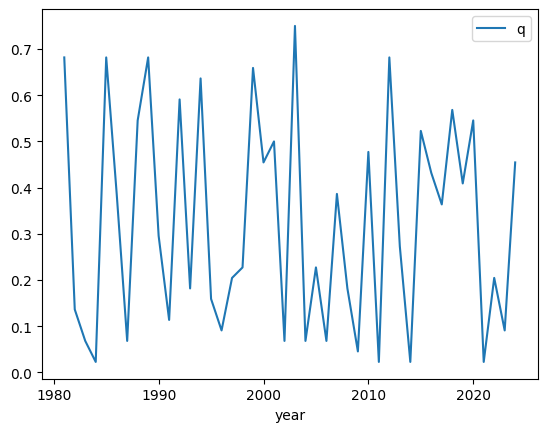

In [61]:
df_era5_rank_q.set_index("issued_month").loc[3].plot(x="year", y="q")

<Axes: xlabel='year'>

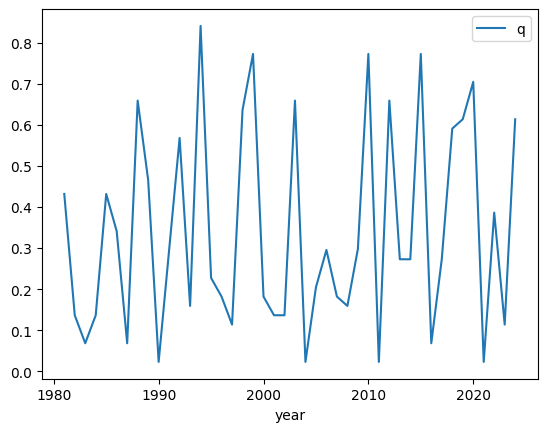

In [62]:
df_era5_rank_q.set_index("issued_month").loc[7].plot(x="year", y="q")

In [63]:
df_era5_rank_q[df_era5_rank_q["year"] >= 2001].sort_values("q")

,issued_month,year,q
74,7,2011,0.022727
40,3,2021,0.022727
67,7,2004,0.022727
84,7,2021,0.022727
30,3,2011,0.022727
33,3,2014,0.022727
28,3,2009,0.045455
23,3,2004,0.068182
25,3,2006,0.068182
79,7,2016,0.068182


In [19]:
df_seas5 = seas5.load_seas5_stats(variable="rank")

In [64]:
df_seas5

,year,issued_month,q
0,1981,3,0.363636
1,1981,7,0.181818
2,1982,3,0.363636
3,1982,7,0.068182
4,1983,3,0.022727
...,...,...,...
83,2022,7,0.750000
84,2023,3,0.409091
85,2023,7,0.840909
86,2024,3,0.545455


In [72]:
df_compare = df_seas5.merge(
    df_era5_rank_q, on=["year", "issued_month"], suffixes=["_s", "_e"]
)
df_compare = df_compare[df_compare["year"] >= 2001]

In [73]:
df_compare["bool_s"] = df_compare["q_s"] < 0.2

In [78]:
df_compare[df_compare["bool_s"]]

,year,issued_month,q_s,q_e,bool_s,bool_e
56,2009,3,0.045455,0.045455,True,True
58,2010,3,0.090909,0.477273,True,False
76,2019,3,0.159091,0.409091,True,False
77,2019,7,0.090909,0.613636,True,False
79,2020,7,0.181818,0.704545,True,False


In [92]:
rp = 10
for mo, group in df_compare.groupby("issued_month"):
    group["bool_e"] = group["q_e"] <= group["q_e"].quantile(1 / rp)

In [93]:
df_compare

,year,issued_month,q_s,q_e,bool_s,bool_e
40,2001,3,0.931818,0.500000,False,False
41,2001,7,0.295455,0.136364,False,True
42,2002,3,0.568182,0.068182,False,True
43,2002,7,0.522727,0.136364,False,True
44,2003,3,0.431818,0.750000,False,False
45,2003,7,0.365909,0.659091,False,False
46,2004,3,0.727273,0.068182,False,True
47,2004,7,0.250000,0.022727,False,True
48,2005,3,0.818182,0.227273,False,False
49,2005,7,0.250000,0.204545,False,False


In [80]:
thresh_e

0.036363636363636376

In [77]:
df_compare[df_compare["bool_e"]]

,year,issued_month,q_s,q_e,bool_s,bool_e
41,2001,7,0.295455,0.136364,False,True
42,2002,3,0.568182,0.068182,False,True
43,2002,7,0.522727,0.136364,False,True
46,2004,3,0.727273,0.068182,False,True
47,2004,7,0.250000,0.022727,False,True
50,2006,3,0.363636,0.068182,False,True
53,2007,7,0.295455,0.181818,False,True
54,2008,3,0.659091,0.181818,False,True
55,2008,7,0.681818,0.159091,False,True
56,2009,3,0.045455,0.045455,True,True


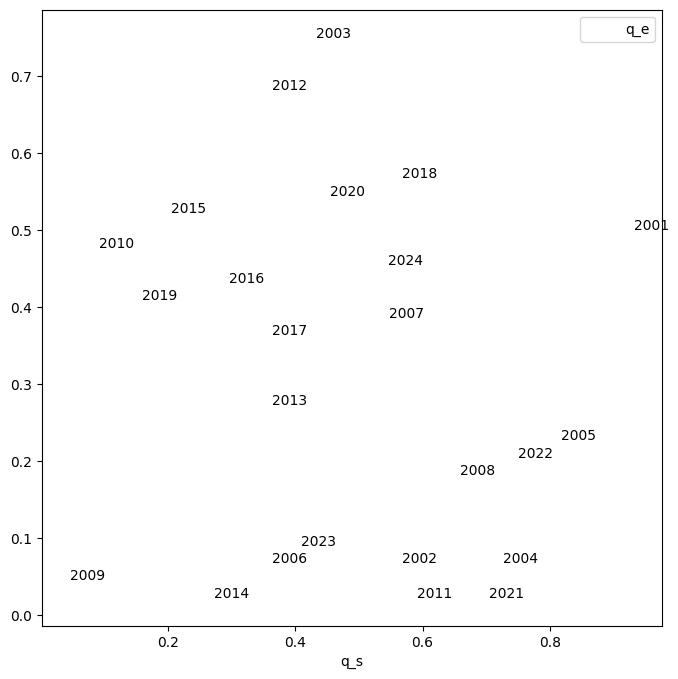

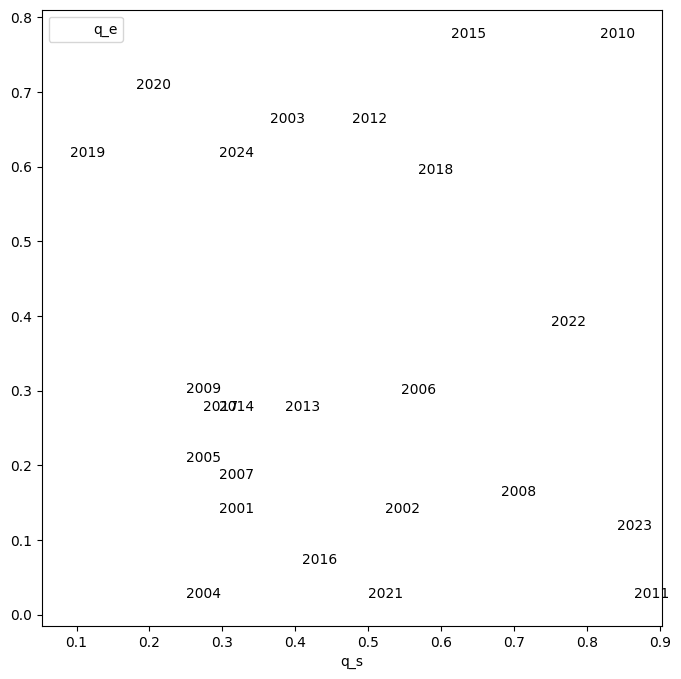

In [89]:
for mo, group in df_compare.groupby("issued_month"):
    fig, ax = plt.subplots(figsize=(8, 8))
    group.plot(x="q_s", y="q_e", linewidth=0, ax=ax)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row["q_s"], row["q_e"]))